# Visualize DGGS Climate Data

This notebook visualizes climate data stored in hierarchical Zarr format with H3 DGGS indexing.

## Prerequisites

This notebook expects a hierarchical Zarr store with H3 DGGS data. If you don"t have one yet, see:
- [Data Preparation Notebook](data_preparation_optimized.ipynb) - Convert NetCDF to H3 DGGS Zarr format

## Overview

This notebook:
1. Loads hierarchical Zarr store with H3 DGGS data
2. Uses `xdggs` library to interpret H3 cell IDs as spatial coordinates
3. Supports multi-resolution exploration

## What you"ll visualize

- Climate variables across Canada
- Multiple H3 resolutions (coarse to fine)
- Globe 3D rendering of H3 data
- Time series data
- Spatial patterns in DGGS cells


## Package Setup


### Installation

Only run this cell if packages are missing.


In [15]:
%%capture
!pip install xarray xdggs zarr h3 numpy pandas geopandas matplotlib longboard "leafmap[maplibre]"


### Imports


In [16]:
import json
import os
import warnings
from pathlib import Path
from typing import Any, cast

import geopandas as gpd
import h3
import ipywidgets as widgets
import leafmap.maplibregl as leafmap
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import xdggs
import zarr
from IPython.display import clear_output
from IPython.display import display
from ipywidgets import interact, Dropdown, IntSlider, interactive_output, VBox, HBox
from matplotlib import colormaps as cm

warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")

print("✅ Packages imported successfully")


✅ Packages imported successfully


## Configuration

Configure the path to your hierarchical Zarr store. By default, this points to the output from the data preparation notebook.


In [17]:
# Path to hierarchical Zarr store with H3 DGGS data
ZARR_PATH = Path(os.getenv(
    "CLIMATE_ZARR_PATH",
    "outputs/dggs/h3/canada_climate_h3_dggs.zarr"
))

# Verify the Zarr store exists
if not ZARR_PATH.exists():
    raise FileNotFoundError(
        f"Zarr store not found: {ZARR_PATH}\n"
        f"Please check the path or run the data preparation notebook first.\n"
        f"See: data_preparation_optimized.ipynb"
    )

print(f"Configuration loaded:")
print(f"  Zarr store: {ZARR_PATH}")
print(f"  Store exists: {ZARR_PATH.exists()}")


Configuration loaded:
  Zarr store: outputs/dggs/h3/canada_climate_h3_dggs.zarr
  Store exists: True


## Step 1: Explore Zarr Store Structure

Inspect the hierarchical Zarr store to understand its structure, available resolutions, variables, and dimensions.

In [18]:
print(f"Exploring Zarr store: {ZARR_PATH}\n")

zarr_root = zarr.open_group(ZARR_PATH, mode="r")

# Get all resolution groups
zarr_groups = sorted([g for g in zarr_root.group_keys()])
print(f"{'='*70}")
print(f"Found {len(zarr_groups)} resolution groups: {zarr_groups}")
print(f"{'='*70}\n")


Exploring Zarr store: outputs/dggs/h3/canada_climate_h3_dggs.zarr

Found 7 resolution groups: ['res0', 'res1', 'res2', 'res3', 'res4', 'res5', 'res6']



In [19]:
for group_name in zarr_groups:
    print(f"\n{'='*70}")
    print(f"Resolution Group: {group_name}")
    print(f"{'='*70}\n")
    ds = xr.open_zarr(ZARR_PATH, group=group_name, decode_timedelta=False)
    display(ds)
    ds.close()



Resolution Group: res0



<xarray.Dataset> Size: 2MB
Dimensions:             (h3_id: 9, time: 1812)
Coordinates:
  * h3_id               (h3_id) uint64 72B 576531121047601151 ... 57723480848...
  * time                (time) datetime64[ns] 14kB 1950-01-01 ... 2100-12-01
Data variables: (12/24)
    ssp126_prcptot_p10  (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp126_prcptot_p50  (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp126_prcptot_p90  (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp126_tx_max_p10   (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp126_tx_max_p50   (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp126_tx_max_p90   (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ...                  ...
    ssp585_prcptot_p10  (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp585_prcptot_p50  (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp585_prcptot_p90  (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp585_tx_max_p10   (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp585_tx_max_p50   (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
    ssp585_tx_max_p90   (h3_id, time) float32 65kB dask.array<chunksize=(9, 12), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.7 CMIP-6.2
    GCM__experiment:              historical,ssp126
    GCM__experiment_id:           historical,ssp126
    GCM__initialization_index:    1
    activity_id:                  CMIP
    cat:_data_format_:            zarr
    ...                           ...
    target__references:           Werner, A.T., Schnorbus, M.A., Shrestha, R....
    target__version:              2.1 (September 2021)
    intake_esm_vars:              prcptot
    cat:id:                       CanDCS-M6_CMIP6_ScenarioMIP_ssp126_CAN
    ensemble_size:                26
    cat:one_var:                  prcptot


Resolution Group: res1



<xarray.Dataset> Size: 6MB
Dimensions:             (h3_id: 35, time: 1812)
Coordinates:
  * h3_id               (h3_id) uint64 280B 581003934349393919 ... 5817340100...
  * time                (time) datetime64[ns] 14kB 1950-01-01 ... 2100-12-01
Data variables: (12/24)
    ssp126_prcptot_p10  (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp126_prcptot_p50  (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp126_prcptot_p90  (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp126_tx_max_p10   (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp126_tx_max_p50   (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp126_tx_max_p90   (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ...                  ...
    ssp585_prcptot_p10  (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp585_prcptot_p50  (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp585_prcptot_p90  (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp585_tx_max_p10   (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp585_tx_max_p50   (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
    ssp585_tx_max_p90   (h3_id, time) float32 254kB dask.array<chunksize=(35, 12), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.7 CMIP-6.2
    GCM__experiment:              historical,ssp126
    GCM__experiment_id:           historical,ssp126
    GCM__initialization_index:    1
    activity_id:                  CMIP
    cat:_data_format_:            zarr
    ...                           ...
    target__references:           Werner, A.T., Schnorbus, M.A., Shrestha, R....
    target__version:              2.1 (September 2021)
    intake_esm_vars:              prcptot
    cat:id:                       CanDCS-M6_CMIP6_ScenarioMIP_ssp126_CAN
    ensemble_size:                26
    cat:one_var:                  prcptot


Resolution Group: res2



...

<xarray.Dataset> Size: 1GB
Dimensions:             (h3_id: 7001, time: 1812)
Coordinates:
  * h3_id               (h3_id) uint64 56kB 594510352364863487 ... 5952441818...
  * time                (time) datetime64[ns] 14kB 1950-01-01 ... 2100-12-01
Data variables: (12/24)
    ssp126_prcptot_p10  (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_prcptot_p50  (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_prcptot_p90  (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_tx_max_p10   (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_tx_max_p50   (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_tx_max_p90   (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ...                  ...
    ssp585_prcptot_p10  (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_prcptot_p50  (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_prcptot_p90  (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_tx_max_p10   (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_tx_max_p50   (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_tx_max_p90   (h3_id, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.7 CMIP-6.2
    GCM__experiment:              historical,ssp126
    GCM__experiment_id:           historical,ssp126
    GCM__initialization_index:    1
    activity_id:                  CMIP
    cat:_data_format_:            zarr
    ...                           ...
    target__references:           Werner, A.T., Schnorbus, M.A., Shrestha, R....
    target__version:              2.1 (September 2021)
    intake_esm_vars:              prcptot
    cat:id:                       CanDCS-M6_CMIP6_ScenarioMIP_ssp126_CAN
    ensemble_size:                26
    cat:one_var:                  prcptot


Resolution Group: res5



<xarray.Dataset> Size: 8GB
Dimensions:             (h3_id: 45661, time: 1812)
Coordinates:
  * h3_id               (h3_id) uint64 365kB 599013945549783039 ... 599747780...
  * time                (time) datetime64[ns] 14kB 1950-01-01 ... 2100-12-01
Data variables: (12/24)
    ssp126_prcptot_p10  (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp126_prcptot_p50  (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp126_prcptot_p90  (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp126_tx_max_p10   (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp126_tx_max_p50   (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp126_tx_max_p90   (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ...                  ...
    ssp585_prcptot_p10  (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp585_prcptot_p50  (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp585_prcptot_p90  (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp585_tx_max_p10   (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp585_tx_max_p50   (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
    ssp585_tx_max_p90   (h3_id, time) float32 331MB dask.array<chunksize=(45661, 12), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.7 CMIP-6.2
    GCM__experiment:              historical,ssp126
    GCM__experiment_id:           historical,ssp126
    GCM__initialization_index:    1
    activity_id:                  CMIP
    cat:_data_format_:            zarr
    ...                           ...
    target__references:           Werner, A.T., Schnorbus, M.A., Shrestha, R....
    target__version:              2.1 (September 2021)
    intake_esm_vars:              prcptot
    cat:id:                       CanDCS-M6_CMIP6_ScenarioMIP_ssp126_CAN
    ensemble_size:                26
    cat:one_var:                  prcptot


Resolution Group: res6



<xarray.Dataset> Size: 36GB
Dimensions:             (h3_id: 207466, time: 1812)
Coordinates:
  * h3_id               (h3_id) uint64 2MB 603517544908718079 ... 60425137993...
  * time                (time) datetime64[ns] 14kB 1950-01-01 ... 2100-12-01
Data variables: (12/24)
    ssp126_prcptot_p10  (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp126_prcptot_p50  (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp126_prcptot_p90  (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp126_tx_max_p10   (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp126_tx_max_p50   (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp126_tx_max_p90   (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ...                  ...
    ssp585_prcptot_p10  (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp585_prcptot_p50  (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp585_prcptot_p90  (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp585_tx_max_p10   (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp585_tx_max_p50   (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
    ssp585_tx_max_p90   (h3_id, time) float32 2GB dask.array<chunksize=(207466, 12), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.7 CMIP-6.2
    GCM__experiment:              historical,ssp126
    GCM__experiment_id:           historical,ssp126
    GCM__initialization_index:    1
    activity_id:                  CMIP
    cat:_data_format_:            zarr
    ...                           ...
    target__references:           Werner, A.T., Schnorbus, M.A., Shrestha, R....
    target__version:              2.1 (September 2021)
    intake_esm_vars:              prcptot
    cat:id:                       CanDCS-M6_CMIP6_ScenarioMIP_ssp126_CAN
    ensemble_size:                26
    cat:one_var:                  prcptot

## Step 2: Load and Decode Data with xdggs

Load a specific resolution group and decode it with xdggs. The library automatically handles all H3 cell ID interpretation and spatial coordinate transformations needed for visualization.


In [20]:
def load_dggs_zarr_group(dggs_res: int) -> xr.Dataset:
    grp = zarr_groups[dggs_res]
    ds = xr.open_zarr(ZARR_PATH, group=grp, decode_timedelta=False)
    ds = ds.rename({"h3_id": "cell_ids"})  # required by 'xdggs.explore()'
    ds_h3 = ds.dggs.decode(grid_info=xdggs.H3Info(level=dggs_res), name="cell_ids")
    return ds_h3


In [21]:
RESOLUTION_LEVEL = 4
RESOLUTION_GROUP = zarr_groups[RESOLUTION_LEVEL]
print(f"Loading resolution group: {RESOLUTION_GROUP}\n")
ds_h3 = load_dggs_zarr_group(RESOLUTION_LEVEL)
print(f"✅ Dataset decoded with H3 DGGS index\n")
display(ds_h3)


Loading resolution group: res4

✅ Dataset decoded with H3 DGGS index



<xarray.Dataset> Size: 1GB
Dimensions:             (cell_ids: 7001, time: 1812)
Coordinates:
  * cell_ids            (cell_ids) uint64 56kB 594510352364863487 ... 5952441...
  * time                (time) datetime64[ns] 14kB 1950-01-01 ... 2100-12-01
Data variables: (12/24)
    ssp126_prcptot_p10  (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_prcptot_p50  (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_prcptot_p90  (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_tx_max_p10   (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_tx_max_p50   (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp126_tx_max_p90   (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ...                  ...
    ssp585_prcptot_p10  (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_prcptot_p50  (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_prcptot_p90  (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_tx_max_p10   (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_tx_max_p50   (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
    ssp585_tx_max_p90   (cell_ids, time) float32 51MB dask.array<chunksize=(7001, 12), meta=np.ndarray>
Indexes:
    cell_ids  H3Index(level=4)
Attributes: (12/46)
    Conventions:                  CF-1.7 CMIP-6.2
    GCM__experiment:              historical,ssp126
    GCM__experiment_id:           historical,ssp126
    GCM__initialization_index:    1
    activity_id:                  CMIP
    cat:_data_format_:            zarr
    ...                           ...
    target__references:           Werner, A.T., Schnorbus, M.A., Shrestha, R....
    target__version:              2.1 (September 2021)
    intake_esm_vars:              prcptot
    cat:id:                       CanDCS-M6_CMIP6_ScenarioMIP_ssp126_CAN
    ensemble_size:                26
    cat:one_var:                  prcptot

## Step 3: Interactive Visualization with Dropdowns

Create interactive visualizations with dropdown controls to switch between variables and time steps, following the xdggs tutorial approach.


### Interactive Map Exploration

Use `xdggs.explore()` with interactive controls for variable and time selection.


In [22]:
# Get available variables
available_vars = [v for v in ds_h3.data_vars if "cell_ids" in ds_h3[v].dims]
print(f"Available variables: {len(available_vars)}")
print(f"Time steps: {len(ds_h3.time) if 'time' in ds_h3.dims else 'No time dimension'}\n")

# Create widgets
zarr_dggs_levels = {res: grp for res, grp in enumerate(zarr_groups)}
dropdown_resolution = Dropdown(
    options=list(zarr_dggs_levels),
    value=RESOLUTION_LEVEL,  # use same previously loaded to start
    description="Resolution:",
    style={"description_width": "100px"}
)

dropdown_variable = Dropdown(
    options=available_vars,
    value=available_vars[0],
    description="Variable:",
    style={"description_width": "100px"}
)

slider_time = IntSlider(
    value=0,
    min=0,
    max=len(ds_h3.time) - 1 if "time" in ds_h3.dims else 0,
    step=1,
    description="Time:",
    style={"description_width": "100px"}
) if "time" in ds_h3.dims else None

# Create output widget for the map
map_output = widgets.Output()


def update_map(change: dict[str, str] | None = None) -> None:
    """
    Update the map when widgets change.
    """
    global ds_h3

    with map_output:
        clear_output(wait=True)

        # change resolution, reload data
        if change and change["owner"] is dropdown_resolution and change["old"] != change["new"]:
            dggs_res = cast(int, change["new"])
            ds_h3 = load_dggs_zarr_group(dggs_res)

        # Get selected variable and time
        var = dropdown_variable.value
        time_idx = slider_time.value if slider_time else 0

        # Load and display data
        if "time" in ds_h3[var].dims:
            data = ds_h3[var].isel(time=time_idx)
            time_val = pd.to_datetime(ds_h3.time.values[time_idx])
            print(f"📊 {var} at {time_val}")
        else:
            data = ds_h3[var]
            print(f"📊 {var}")

        # Compute and display
        data = data.compute()
        print(f"   Value range: {float(data.min()):.2f} to {float(data.max()):.2f}")
        print(f"   Creating map...")

        try:
            map_widget = data.dggs.explore(cmap="RdYlBu_r", alpha=0.7)
            map_widget.layout.height = "800px"
            map_widget.map.layout.height = "800px"
            display(map_widget)
        except Exception as e:
            print(f"   ⚠️ Error creating map: {e}")
            print(f"   Map visualization not available in this environment")

# Attach event handlers
dropdown_resolution.observe(update_map, names="value")
dropdown_variable.observe(update_map, names="value")
if slider_time:
    slider_time.observe(update_map, names="value")

# Display widgets and initial map
display_options = [dropdown_resolution, dropdown_variable]
if slider_time:
    display_options.append(slider_time)
display(HBox(display_options))
display(map_output)

# Trigger initial map display
update_map({})


Available variables: 24
Time steps: 1812



Output()

## Step 4: Globe 3D rendering of H3 climate variables

This demonstrates an alternative representation using a 3D globe visualization.

This can be useful to visualize one of the nice properties of DGGS zones with approximate areas (in case of H3) or equal areas for others.
As shown on the previous maps, the 2D map projections create an impression of small-to-large zone areas from lower to higher latitudes.
This will be avoided with the 3D view better respecting the ellipsoid visualization of the Earth.


In [23]:
def dggs_to_gdf(dggs_res_level: int, variable: str, time_index: int | None) -> gpd.GeoDataFrame:
    """
    Convert the ``xdggs`` data to GeoPandas GeoDataFrame.

    This conversion is needed since the globe utilities relies on GeoJSON polygons.
    """
    dggs_ds = load_dggs_zarr_group(dggs_res_level)
    dggs_arr = dggs_ds[variable]
    if time_index is not None:
        dggs_arr = dggs_arr.isel(time=time_index)

    # Capture geometry and IDs while the DGGS index is still valid
    # xdggs needs the index to calculate these
    dggs_geom = dggs_arr.dggs.cell_boundaries()  # array of polygons
    ids_array = dggs_arr.cell_ids.values

    # Convert to a Dataset and strip the custom H3Index entirely to avoid errors
    ds_clean = dggs_arr.drop_vars("cell_ids").drop_indexes(["cell_ids"], errors="ignore")

    # Convert to DataFrame and manually re-attach the IDs and the Geometry
    df = ds_clean.to_dataframe().reset_index()
    df["cell_ids"] = ids_array
    df["geometry"] = dggs_geom

    df["geometry"] = dggs_geom
    dggs_gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
    return dggs_gdf

In [24]:
dggs_to_gdf(2, 'ssp126_prcptot_p10', 0)

,cell_ids,time,ssp126_prcptot_p10,geometry
0,585503685686067199,1950-01-01,4.303453,"POLYGON ((-109.60061 80.79477, -116.06967 79.5..."
1,585504235441881087,1950-01-01,5.820197,"POLYGON ((-99.38614 78.71664, -105.80712 77.63..."
2,585504785197694975,1950-01-01,5.366172,"POLYGON ((-116.06967 79.50059, -125.12063 79.5..."
3,585505334953508863,1950-01-01,5.433128,"POLYGON ((-113.25348 77.98718, -117.96273 76.6..."
4,585505884709322751,1950-01-01,3.694973,"POLYGON ((-90.3811 82.85349, -102.68418 83.576..."
...,...,...,...,...
184,586234860918538239,1950-01-01,64.120773,"POLYGON ((-79.38816 48.82734, -81.91963 48.295..."
185,586235410674352127,1950-01-01,68.492294,"POLYGON ((-78.10037 45.98243, -80.49026 45.493..."
186,586235960430166015,1950-01-01,72.983299,"POLYGON ((-71.44638 50.08274, -74.1423 49.7244..."
187,586236510185979903,1950-01-01,82.473885,"POLYGON ((-70.65056 47.1461, -73.17262 46.8116..."


In [32]:
def render_globe_from_gdf(
    gdf: gpd.GeoDataFrame,
    value_col: str = "value",
    cmap: str = "RdYlBu_r",
) -> Any:
    """
    Render a GeoDataFrame on a 3D globe using leafmap (MapLibre backend).
    """
    # Initialize map with globe projection
    # m = leafmap.Map(
    #     center=[0, 20], 
    #     zoom=1, 
    #     pitch=0, 
    #     height="600px",
    #     projection="globe" 
    # )

    # # Just pass the GDF directly. No json.loads() or to_json() needed.
    # m.add_gdf(
    #     gdf,
    #     #layer_name="DGGS Data",
    #     #color_column=value_col,
    #     #fill_colors=cmap,
    #     #opacity=0.8
    # )
    # return m
    m = leafmap.Map(
        center=[20, 0], # Note: maplibregl uses [lon, lat]
        zoom=1, 
        pitch=0, 
        height="800px",
        projection="globe",
        style="dark-matter" # Dark backgrounds make globes pop
    )

    # Use add_data for automatic color mapping
    m.add_data(
        gdf,
        column=value_col,   # The column to scale colors by
        cmap=cmap,          # The colormap name
        opacity=0.8,
        name="DGGS Data"
    )
    
    return m

def render_and_display(dggs_gdf: gpd.GeoDataFrame) -> None:
    m = render_globe_from_gdf(
        dggs_gdf,
        value_col=state["var"],
        cmap=state["cmap"]
    )

    with out:
        clear_output(wait=True)
        # Directly display the map widget; no .to_html() needed
        display(m)

def update_globe(change: dict[str, Any]) -> None:
    if change.get("name") != "value" and state["data"] is not None:
        return
    source = change.get("owner")
    new = change.get("new")
    if source is dropdown_colormap:
        if state["cmap"] == new:
            return
        state["cmap"] = new
    elif source is dropdown_resolution:
        if state["level"] == new:
            return
        state["level"] = new

    state["data"] = dggs_gdf = dggs_to_gdf(state["level"], state["var"], state["time"])
    render_and_display(dggs_gdf)


out = widgets.Output(layout=widgets.Layout(height="720px"))  # reserve height

# Display widgets
# NOTE: reuse the previous definitions for simplicity
dropdown_colormap = widgets.Dropdown(options=list(plt.colormaps()), value="RdYlBu_r", description="Colour Map")

# Keep previous states to avoid duplicate renders
state = {
    "cmap": dropdown_colormap.value,
    "data": None,  # will be populated on first run
    "level": RESOLUTION_LEVEL,
    "time": slider_time.value if slider_time else None,
    "var": dropdown_variable.value,
}

dropdown_resolution.observe(update_globe, names="value")
dropdown_variable.observe(update_globe, names="value")
display_options = [dropdown_resolution, dropdown_variable]
if slider_time:
    slider_time.observe(update_globe, names="value")
    display_options.append(slider_time)
dropdown_colormap.observe(update_globe, names="value")
display_options.append(dropdown_colormap)

display(widgets.HBox(display_options))
display(out)

# initial render
update_globe(state)
render_and_display(state["data"])

Output(layout=Layout(height='720px'))

## Step 5: Time Series Visualization

If the data has a time dimension, visualize how values change over time for a specific H3 cell.


Creating time series visualization for ssp126_prcptot_p10...


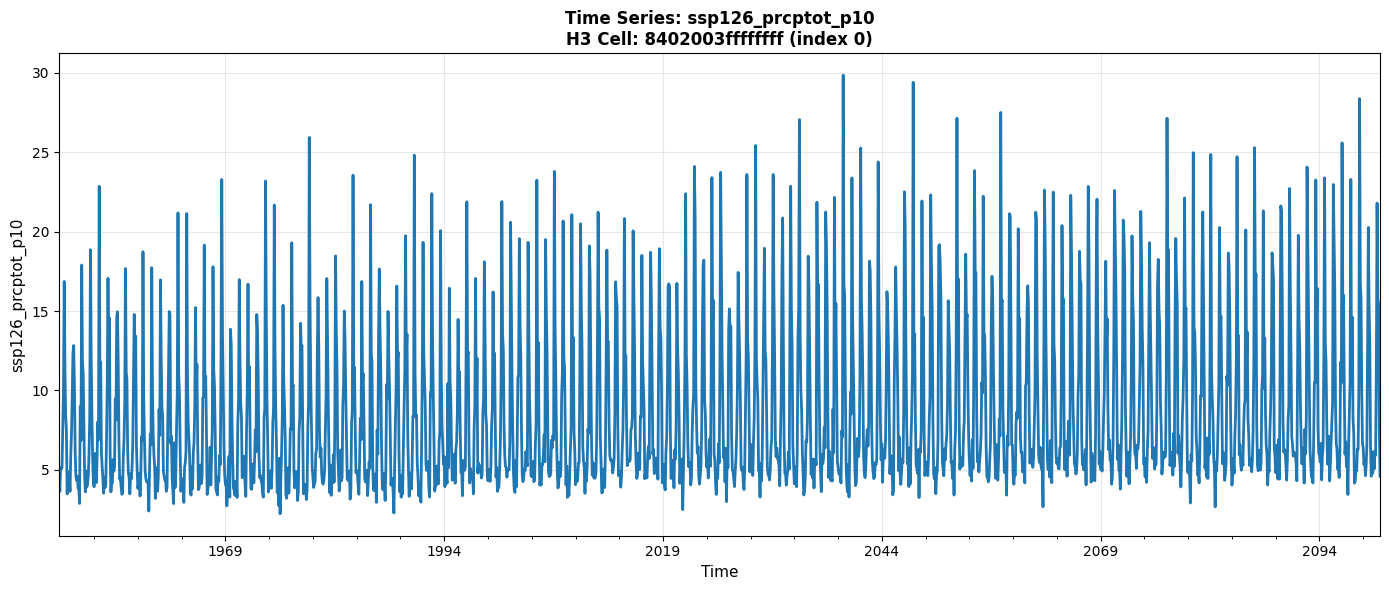


Time series statistics for cell 0:
count    1812.000000
mean        8.523967
std         5.087120
min         2.234347
25%         4.910420
50%         6.383152
75%        10.903787
max        29.854799
Name: ssp126_prcptot_p10, dtype: float64


In [23]:
# Select first available variable for time series demo
demo_var = available_vars[0]

if "time" in ds_h3[demo_var].dims:
    print(f"Creating time series visualization for {demo_var}...")

    # Select a cell to show time series
    CELL_INDEX = 0  # Change this to select different cells

    cell_id = ds_h3["cell_ids"].values[CELL_INDEX]

    # Get time series for this cell
    time_series = ds_h3[demo_var].isel(cell_ids=CELL_INDEX)

    # Convert to pandas for easier plotting
    df = time_series.to_dataframe()

    # Plot time series
    fig, ax = plt.subplots(figsize=(14, 6))
    df[demo_var].plot(ax=ax, linewidth=2)

    ax.set_title(
        f"Time Series: {demo_var}\n"
        f"H3 Cell: {h3.int_to_str(cell_id)} (index {CELL_INDEX})",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel(demo_var, fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show statistics
    print(f"\nTime series statistics for cell {CELL_INDEX}:")
    print(df[demo_var].describe())
else:
    print(f"No time dimension available for {demo_var}")


## Step 6: Compare Multiple Resolutions

Visualize the same variable at different H3 resolutions using xdggs to see the multi-resolution structure.


In [10]:
def compare_resolutions_interactive(zarr_path, groups, variable, time_index=0):
    """
    Compare the same variable across multiple resolutions with interactive maps.

    Args:
        zarr_path: Path to Zarr store
        groups: List of resolution group names to compare
        variable: Variable name to visualize
        time_index: Time index to select (if time dimension exists)
    """
    print(f"Comparing variable '{variable}' across {len(groups)} resolutions:\n")

    for group in groups:
        print(f"\n{"="*70}")
        print(f"Resolution: {group}")
        print(f"{"="*70}")

        ds = xr.open_zarr(zarr_path, group=group, decode_timedelta=False)
        ds = ds.rename({"h3_id": "cell_ids"})
        ds = ds.dggs.decode(grid_info=xdggs.H3Info(level=0), name="cell_ids")

        if variable not in ds.data_vars:
            print(f"Variable '{variable}' not found in {group}")
            ds.close()
            continue

        if "time" in ds[variable].dims:
            data = ds[variable].isel(time=time_index)
            time_val = pd.to_datetime(ds.time.values[time_index])
            print(f"Time: {time_val}")
        else:
            data = ds[variable]

        print(f"Cells: {ds.sizes["cell_ids"]:,}")

        # Load data into memory before computing stats and visualizing
        data = data.compute()

        print(f"Value range: {float(data.min()):.2f} to {float(data.max()):.2f}")

        # Use xdggs.explore() for interactive visualization
        map_widget = data.dggs.explore(cmap="RdYlBu_r", alpha=0.7)
        display(map_widget)

        ds.close()

# Compare resolutions (must match Zarr group names)
groups_to_compare = ["res2", "res4", "res5"]
print(f"Comparing resolutions: {groups_to_compare}\n")

compare_resolutions_interactive(
    ZARR_PATH,
    groups_to_compare,
    available_vars[0],
    time_index=0
)


Comparing resolutions: ['res2', 'res4', 'res5']

Comparing variable 'ssp126_prcptot_p10' across 3 resolutions:


Resolution: res2
Time: 1950-01-01 00:00:00
Cells: 189
Value range: 2.14 to 277.57


MapWithControls(colorbar=Colorbar(colors=[[0.19215686274509805, 0.21176470588235294, 0.5843137254901961], [0.1…


Resolution: res4
Time: 1950-01-01 00:00:00
Cells: 7,001
Value range: 0.00 to 564.26


MapWithControls(colorbar=Colorbar(colors=[[0.19215686274509805, 0.21176470588235294, 0.5843137254901961], [0.1…


Resolution: res5
Time: 1950-01-01 00:00:00
Cells: 45,661
Value range: 0.00 to 792.57


MapWithControls(colorbar=Colorbar(colors=[[0.19215686274509805, 0.21176470588235294, 0.5843137254901961], [0.1…